In [169]:
import os
from typing import TypedDict,Annotated,List, Literal
from langchain_core.messages import BaseMessage, HumanMessage,AIMessage,SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

In [170]:
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [171]:
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode

In [172]:
class AgentState(MessagesState):
    next_agent:str

In [173]:
@tool
def search_web(query:str)->str:
    """Search the web for information"""
    search=TavilySearchResults(max_result=3)
    results=search.invoke(query)
    return str(results)

@tool
def write_summary(content:str)->str:
    """Write a summary of the provided content"""
    summary=f"Summary of findings:\n\n{content[:500]}..."
    return summary


In [174]:
llm=ChatOpenAI()

In [175]:
def researcher_agent(state:AgentState):
    """Researcher agent that searches for information"""
    messages=state["messages"]

    system_msg=SystemMessage(content="You are research assistant. Use the search_web tool to find information about user's request.")

    researcher_llm= llm.bind_tools([search_web])
    response=researcher_llm.invoke([system_msg]+messages)
    return {
        "messages":[response],
        "next_agent":"writer"
    }


In [176]:
def writer_agent(state:AgentState):
    """Writes agent that creates summaries"""

    messages=state["messages"]
    system_msg=SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    response= llm.invoke([system_msg]+messages)

    return{
        "messages":[response],
        "next_agent":"end"
    }

In [177]:
def execute_tools(state:AgentState):
    """Execute my pending tools calls"""
    messages=state["messages"]
    last_message=messages[-1]

    if hasattr(last_message,"tool_calls") and last_message.tool_calls:
        tool_node=ToolNode([search_web,write_summary])
        response=tool_node.invoke(state)
        return response
    
    return state

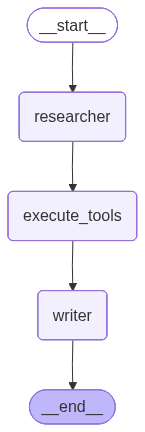

In [178]:
workflow=StateGraph(MessagesState)

workflow.add_node("researcher",researcher_agent)
workflow.add_node("writer",writer_agent)
workflow.add_node("execute_tools",execute_tools)


workflow.set_entry_point("researcher")
workflow.add_edge("researcher","execute_tools")
workflow.add_edge("execute_tools","writer")
workflow.add_edge("writer",END)

final_workflow=workflow.compile()
final_workflow


In [179]:
response=final_workflow.invoke({"messages": [HumanMessage(content="Research about the usecase of agentic ai in business")]})
response["messages"][-1].content

'Agentic AI is being increasingly utilized in various business operations to enhance efficiency and strategic decision-making. Some notable use cases include:\n\n1. Predictive maintenance in manufacturing: Agentic AI agents monitor equipment performance, detect anomalies, and schedule preventive maintenance, leading to reduced downtime and extended machine lifespan.\n   \n2. Compliance and risk monitoring: In regulated industries such as finance and healthcare, Agentic AI ensures compliance by real-time monitoring of transactions, logs, and communications.\n\n3. Personalized upselling: Agentic AI is used for recognizing customer readiness for upgrades and facilitating personalized upselling opportunities.\n\nBusinesses are leveraging Agentic AI to automate tasks, make informed decisions, and drive measurable impacts across different sectors like manufacturing, customer service, human resources, and more. The early adoption of Agentic AI can lead to transformative benefits in terms of o